In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pymultinest
from getdist import plots, MCSamples
import time

## MOPED compression
Determine the number of sims needed to accurate compression.

In [2]:
def model(params, p, base=None):
    if base is None:
        base = np.linspace(0, 5, p)
    # Example: 4 param model
    # out  = params[0]*np.exp(-params[1]*base) * (1+params[2]*np.exp(-(base-params[3])**2)/3)
    # Example: 3 param model
    out = params[0] * np.exp(-params[1]*base) + params[2]*np.exp(-(base-2.5)**2/2/0.3**2)
    return out

In [3]:
def compute_moped_matrix(ic, params, dp=0.01, sel=None):
    # dim os params
    m = len(params)

    p = ic.shape[0]
    if sel is None:
        sel = np.ones(p, dtype=bool)
    psub= np.sum(sel)

    print('Compressing {} -> {}'.format(psub, m))

    derivatives = np.zeros((m, psub))
    for i in range(m):
        # plus
        pp = params.copy()
        pp[i] *= 1+dp
        k_plus = model(pp,p)[sel]
        # plus 2
        pp2 = params.copy()
        pp2[i] *= 1+2*dp
        k_plus2 = model(pp2,p)[sel]
        # minus
        pm = params.copy()
        pm[i] *= 1-dp
        k_minus = model(pm,p)[sel]
        # minus 2
        pm2 = params.copy()
        pm2[i] *= 1-2*dp
        k_minus2 = model(pm2,p)[sel]
        # derivative
        h = params[i] * dp
        d = (-k_plus2 + 8*k_plus - 8*k_minus + k_minus2) / 12/h
        # assign
        derivatives[i] = d

    # compute the moped matrix
    c = np.linalg.inv(ic[np.ix_(sel, sel)])
    b = np.zeros((m,psub))
    for i in range(m):
        mum_bq = np.einsum('i,qi->q', derivatives[i], b)
        bm = np.dot(ic[np.ix_(sel, sel)], derivatives[i])
        bm-= np.einsum('q,qi->i', mum_bq, b)
        bm/= np.abs(np.einsum('i,ij,j->', bm, c, bm))**0.5
        # update matrix
        b[i,:] = bm

    # set identity matrix for uncompressed data vectors
    m2 = p-psub # length of uncompressed DV
    b_full = np.zeros((m+m2,p))
    b_full[:m, sel] = b
    b_full[m:,~sel] = np.eye(m2)

    return b_full

In [34]:
def lnpost(data, params, ic, b=None, boundary=None, compressed_ic=None):
    theo = model(params, len(data))
    if b is not None:
        data = np.dot(b, data)
        theo = np.dot(b, theo)
    if b is not None and compressed_ic is None:
        c = np.linalg.inv(ic)
        c = np.dot(b, np.dot(c, b.T))
        ic= np.linalg.inv(c)
    elif b is not None and compressed_ic is not None:
        ic = compressed_ic
    diff = data - theo
    chi2 = np.dot(diff, np.dot(ic, diff))
    out = -0.5*chi2

    if boundary is not None:
        for i in range(len(params)):
            if params[i] < boundary[i][0] or params[i] > boundary[i][1]:
                out = -np.inf
    return out

def sample_param(data, ic, params, b=None, nwalkers=10, boundary=None, f_hartlap=1):
    # def temporary_lnpost(params):
    #     return lnpost(data, params, ic, b, boundary) * f_hartlap
    # ndim = len(params)
    # pos = [params + 1e-4*np.random.randn(ndim) for i in range(nwalkers)]
    # sampler = emcee.EnsembleSampler(nwalkers, ndim, temporary_lnpost)
    # sampler.run_mcmc(pos, 2000)
    # samples = sampler.get_chain(discard=100, thin=15, flat=True)
    # return samples

    if b is not None:
        c = np.linalg.inv(ic)
        c = np.dot(b, np.dot(c, b.T))
        compressed_ic = np.linalg.inv(c)
    else:
        compressed_ic = None

    def lnpost_temp(cube, ndim, nparams):
        params = cube
        return lnpost(data, params, ic, b, compressed_ic=compressed_ic) * f_hartlap

    def prior_temp(cube, ndim, nparams):
        for i in range(ndim):
            cube[i] = cube[i] * (boundary[i][1] - boundary[i][0]) + boundary[i][0]
    
    n_params = len(params)
    pymultinest.run(lnpost_temp, prior_temp, n_params, outputfiles_basename='../output/moped-toy/temp', resume=False, verbose=False, n_live_points=200, evidence_tolerance=0.05)

    samples = np.loadtxt('../output/moped-toy/temp.txt')
    weight = samples[:,0]
    samples = samples[:,2:]

    print(f_hartlap)
    return samples, weight

#### Noiseless data case

In [35]:
rng = np.random.default_rng(0)

In [36]:
def run_for_pN(p, N):
    """
    p: number of data points
    N: number of simulations
    """
    # data
    params = [3, 0.5, 5]
    data = model(params, p)

    # true covariance
    c = np.diag(data*0.05)
    ic= np.linalg.inv(c)

    # sim cov
    x = rng.multivariate_normal(np.zeros(p), c, N)
    c_est = np.cov(x.T)
    ic_est= np.linalg.inv(c_est)

    names = ['a', 'b', 'c']
    boundary = [[0, 5], [0, 2], [0, 10]]

    # 1. with true covariance
    samples, w = sample_param(data, ic, params, boundary=boundary)
    mcs = MCSamples(samples=samples, names=names, label='True', weights=w)

    # 3. moped compression
    b = compute_moped_matrix(ic_est, params)
    samples, w = sample_param(data, ic_est, params, b=b, boundary=boundary, f_hartlap=(N-len(params)-2)/(N-1))
    mcs_moped = MCSamples(samples=samples, names=names, label=f'MOPED', weights=w)

    return mcs, mcs_moped

In [37]:
def run_for_p(p):
    N = np.linspace(1.7*p, 50*p, 25).astype(int)
    print(N, N.size)

    fom_ratio = []
    for _ in N:
        mcs, mcs_moped = run_for_pN(p, _)
        fom1= np.linalg.det(mcs.getCov())**-0.5
        fom2= np.linalg.det(mcs_moped.getCov())**-0.5
        fom_ratio.append(fom2/fom1)
    fom_ratio = np.array(fom_ratio)

    return N, fom_ratio

In [38]:
res = {}
for p in [50, 100, 150, 200]:
    t0 = time.time()
    res[p] = run_for_p(p)
    print(p, time.time()-t0)

[  85  185  286  386  487  588  688  789  890  990 1091 1191 1292 1393
 1493 1594 1695 1795 1896 1996 2097 2198 2298 2399 2500] 25
 *****************************************************
 MultiNest v3.10
 Copyright Farhan Feroz & Mike Hobson
 Release Jul 2015

 no. of live points =  200
 dimensionality =    3
 *****************************************************
 ln(ev)=  -9.4882511318451055      +/-  0.19959178959296847     
 Total Likelihood Evaluations:         3501
 Sampling finished. Exiting MultiNest
1
Removed no burn in
Compressing 50 -> 3
 *****************************************************
 MultiNest v3.10
 Copyright Farhan Feroz & Mike Hobson
 Release Jul 2015

 no. of live points =  200
 dimensionality =    3
 *****************************************************
 ln(ev)=  -10.594217272659936      +/-  0.21293942697239990     
 Total Likelihood Evaluations:         3872
 Sampling finished. Exiting MultiNest
0.9523809523809523
Removed no burn in
 ***************************

/var/folders/1m/ncv9_zyd2jx24czdhnwkm_3w0000gn/T/ipykernel_96316/3433445516.py:10: RuntimeWarning: divide by zero encountered in reciprocal
  plt.plot(x, x**-1, color='k', ls='--', label=r'$y\propto x^{-1}$')


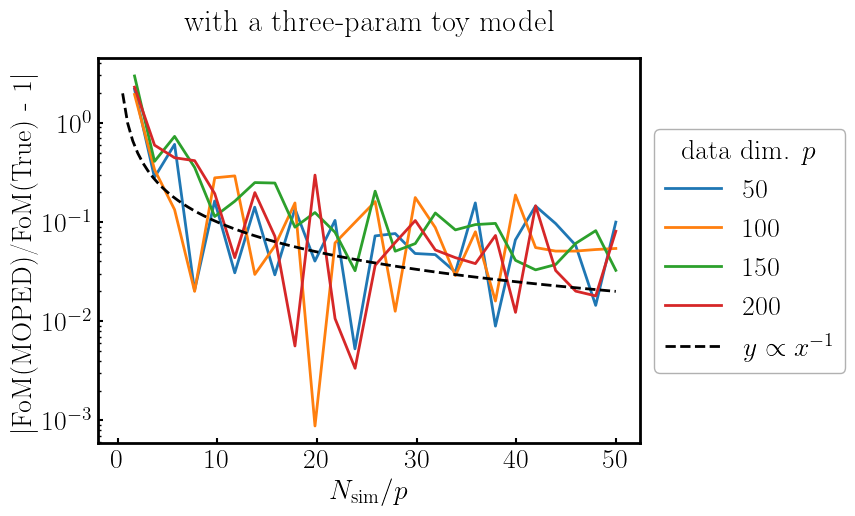

In [48]:
plt.figure()
for p in res.keys():
    N, fom_ratio = res[p]
    plt.plot(N/p, np.abs(fom_ratio-1), label=f'{p}')
    # plt.plot(N/p, np.abs(fom_ratio * ((N-p-2)/(N-1))-1), label=f'{p}')
plt.ylabel(r'|FoM(MOPED)/FoM(True) - 1|')
plt.xlabel(r'$N_{\rm sim}/p$')
# plt.axhline(1, color='k', ls='--')
x = np.linspace(0, 50, 100)
plt.plot(x, x**-1, color='k', ls='--', label=r'$y\propto x^{-1}$')
plt.legend(title=r'data dim. $p$', loc='center left', bbox_to_anchor=(1,0.5))
plt.title(r'with a three-param toy model')
plt.yscale('log')
plt.show()